# 지연 경험 고객 재구매율 비교

## 분석 목적
배송 **지연(Late Delivery)** 을 경험한 고객과 그렇지 않은 고객 사이에
**재구매율(Repurchase Rate)** 에 차이가 있는지 비교한다.
즉, *"나쁜 배송 경험이 고객을 떠나게 만드는가?"* 를 데이터로 확인한다.

## 분석 데이터
- `olist_order_item_level.csv` : 주문-상품(order-item) 단위로 정제된 통합 테이블
- 본 노트북과 **같은 폴더**에 위치하므로 모든 경로는 **상대 경로**로 불러온다.

## 분석 관점 (3단계)
| 단계 | 관점 | 정의 | 의미 |
|------|------|------|------|
| 관점 A | 지연 경험 **여부** | 한 번이라도 지연을 겪은 고객 vs 아닌 고객 | 전체적인 경향 파악 |
| 관점 B | **첫 주문** 지연 여부 | 첫 주문이 지연된 고객의 재방문율 | 선후관계(편향) 통제 |
| 관점 C | 지연 **정도** | 지연 일수 구간별 재구매율 | 용량-반응(dose-response) 확인 |

마지막으로 **카이제곱 검정**으로 차이의 통계적 유의성을 확인한다.

> ⚠️ **유의점** : Olist 데이터는 고객 1인당 주문이 대부분 1건인 *낮은 재구매율* 구조다.
> 따라서 절대 재구매율(약 3%)보다 **그룹 간 상대적 차이**에 주목해 해석한다.


## 0. 환경 설정 및 시각화 서식 통일

팀 노트북과 동일하게 **Malgun Gothic** 한글 폰트 + seaborn `whitegrid` 테마를 사용한다.
모든 그래프가 같은 형식을 갖도록 아래 공통 상수/헬퍼를 정의한다.
- `PALETTE` : 그룹별 고정 색상 (지연=빨강, 정시=초록)
- `FIGSIZE` : 단일 그래프 기본 크기
- `annotate_bars()` : 막대 위 수치 라벨을 통일된 형식으로 표기


In [1]:
# 기본 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 경로 / 통계
from pathlib import Path
from scipy import stats

# 한글 그래프 폰트 설정 - Windows/Jupyter
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

# ── 시각화 공통 서식 ──────────────────────────────────────────────
PALETTE = {"지연 경험": "#C0392B", "정시 배송": "#2E7D5B"}   # 그룹별 고정 색상
ORDER   = ["정시 배송", "지연 경험"]                          # 범례/축 순서 고정
FIGSIZE = (8, 5)                                              # 단일 그래프 기본 크기
TITLE_FS, LABEL_FS = 14, 12                                   # 폰트 크기 통일

def annotate_bars(ax, fmt="{:.1%}", fontsize=12):
    """막대 위에 값 라벨을 통일된 형식으로 표기."""
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom",
                        fontsize=fontsize, fontweight="bold")

print("✅ 환경 설정 완료 / 폰트:", plt.rcParams["font.family"])

✅ 환경 설정 완료 / 폰트: ['Malgun Gothic']


## 1. 데이터 불러오기

같은 폴더의 CSV를 **상대 경로**로 불러온다.

In [2]:
# 상대 경로 사용 (노트북과 동일 폴더)
DATA_PATH = "olist_order_item_level.csv"

raw = pd.read_csv(DATA_PATH)
print(f"원본 shape : {raw.shape[0]:,} 행 × {raw.shape[1]} 열  (order-item 단위)")
raw.head(3)

원본 shape : 112,650 행 × 67 열  (order-item 단위)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total,customer_id,order_status,...,payment_value_total,payment_installments_max,payment_type_nunique,payment_types,review_score_mean,review_count,review_creation_min,review_answer_max,seller_customer_same_state,delivery_route
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,72.19,3ce436f183e68e07877b285a838db11a,delivered,...,72.19,2.0,1.0,credit_card,5.0,1.0,2017-09-21 00:00:00,2017-09-22 10:57:03,False,SP -> RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,...,259.83,3.0,1.0,credit_card,4.0,1.0,2017-05-13 00:00:00,2017-05-15 11:34:13,True,SP -> SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,...,216.87,5.0,1.0,credit_card,5.0,1.0,2018-01-23 00:00:00,2018-01-23 16:06:31,True,MG -> MG


## 2. 주문(order) 단위 데이터 구성

원본은 **주문-상품** 단위라 한 주문이 여러 행으로 중복될 수 있다.
재구매 분석은 *주문/고객* 단위이므로 다음과 같이 정리한다.

1. `order_id` 기준 **중복 제거** → 주문 1건 = 1행
2. **배송 완료(`is_delivered == True`)** 주문만 사용
   → 지연 여부(`is_late`)는 배송이 완료되어야 정의되기 때문
3. **이상치(`anomaly_flag == 1`)** 주문 제외 → 날짜 오류 등 신뢰도 낮은 주문 배제
4. 지연 일수(`late_days`)를 직접 계산
   → `late_days = 실제 배송 완료일 − 도착 예정일` (양수일수록 더 늦음)


In [3]:
# 1) 주문 단위로 중복 제거
order_level = raw.drop_duplicates(subset="order_id").copy()

# 2) 배송 완료 + 3) 이상치 제외
order_level = order_level[
    order_level["is_delivered"].eq(True)
    & order_level["anomaly_flag"].eq(0)
].copy()

# 4) 지연 일수 계산 (예정일 대비 실제 도착일)
delivered = pd.to_datetime(order_level["order_delivered_customer_date"], errors="coerce")
estimated = pd.to_datetime(order_level["order_estimated_delivery_date"], errors="coerce")
order_level["late_days"] = (delivered - estimated).dt.total_seconds() / 86400

# 구매 시각(첫 주문 판별용)
order_level["purchase_ts"] = pd.to_datetime(order_level["order_purchase_timestamp"], errors="coerce")

# is_late 결측 정리 (배송완료 주문이므로 late_days로 보정)
order_level["is_late"] = order_level["is_late"].fillna(order_level["late_days"] > 0).astype(bool)

print(f"분석 대상 주문 수 : {order_level['order_id'].nunique():,} 건")
print(f"고유 고객 수      : {order_level['customer_unique_id'].nunique():,} 명")
print(f"지연 주문 비율    : {order_level['is_late'].mean():.1%}")
order_level[["order_id", "customer_unique_id", "purchase_ts", "is_late", "late_days"]].head()

분석 대상 주문 수 : 95,082 건
고유 고객 수      : 92,025 명
지연 주문 비율    : 8.2%


,order_id,customer_unique_id,purchase_ts,is_late,late_days
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,False,-8.011250
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,False,-2.330278
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,False,-13.444954
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,False,-5.435660
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,False,-15.303808


## 3. 고객 단위 지표 만들기

주문 단위 데이터를 **고객(`customer_unique_id`)** 단위로 집계한다.

- `n_orders` : 고객의 총 주문 수
- `repurchased` : 주문이 2건 이상이면 **재구매 고객**(True)
- `ever_late` : 한 번이라도 지연을 경험했으면 True (→ 관점 A)
- 첫 주문 정보 : 가장 빠른 구매 시각의 주문 → 첫 주문 지연 여부/지연 일수 (→ 관점 B·C)


In [4]:
# 구매 시각 순으로 정렬 후 고객별 집계
order_sorted = order_level.sort_values("purchase_ts")

cust = order_sorted.groupby("customer_unique_id").agg(
    n_orders=("order_id", "nunique"),
    ever_late=("is_late", "max"),                 # 한 번이라도 지연 → True
    first_late=("is_late", "first"),              # 첫 주문 지연 여부
    first_late_days=("late_days", "first"),       # 첫 주문 지연 일수
).reset_index()

cust["repurchased"] = cust["n_orders"] > 1        # 재구매 여부
cust["ever_late"]  = cust["ever_late"].astype(bool)
cust["first_late"] = cust["first_late"].astype(bool)

# 그룹 라벨(시각화 서식 통일용)
label_map = {True: "지연 경험", False: "정시 배송"}
cust["ever_late_grp"]  = cust["ever_late"].map(label_map)
cust["first_late_grp"] = cust["first_late"].map(label_map)

print(f"전체 고객 수      : {len(cust):,} 명")
print(f"재구매 고객 수    : {cust['repurchased'].sum():,} 명")
print(f"전체 재구매율     : {cust['repurchased'].mean():.2%}")
cust.head()

전체 고객 수      : 92,025 명
재구매 고객 수    : 2,744 명
전체 재구매율     : 2.98%


,customer_unique_id,n_orders,ever_late,first_late,first_late_days,repurchased,ever_late_grp,first_late_grp
0,0000366f3b9a7992bf8c76cfdf3221e2,1,False,False,-4.132905,False,정시 배송,정시 배송
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,False,False,-4.248125,False,정시 배송,정시 배송
2,0000f46a3911fa3c0805444483337064,1,False,False,-1.389734,False,정시 배송,정시 배송
3,0000f6ccb0745a6a4b88665a16c9f078,1,False,False,-11.108970,False,정시 배송,정시 배송
4,0004aac84e0df4da2b147fca70cf8255,1,False,False,-7.035463,False,정시 배송,정시 배송


## 4. [관점 A] 지연 경험 *여부* 별 재구매율

한 번이라도 지연을 경험한 고객(`지연 경험`)과 그렇지 않은 고객(`정시 배송`)의 재구매율을 비교한다.

> 단순·직관적이지만, *주문이 많을수록 지연을 겪을 확률도 높아지는* 구조적 편향이 있다.
> (재구매 고객은 주문이 많아 자동으로 '지연 경험'에 분류되기 쉬움) → 관점 B에서 보완한다.


,그룹,고객수,재구매고객수,재구매율
0,정시 배송,84288,2387,0.028320
1,지연 경험,7737,357,0.046142


C:\Users\함다연\AppData\Local\Temp\ipykernel_13976\950337931.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp_a, x="그룹", y="재구매율", order=ORDER,


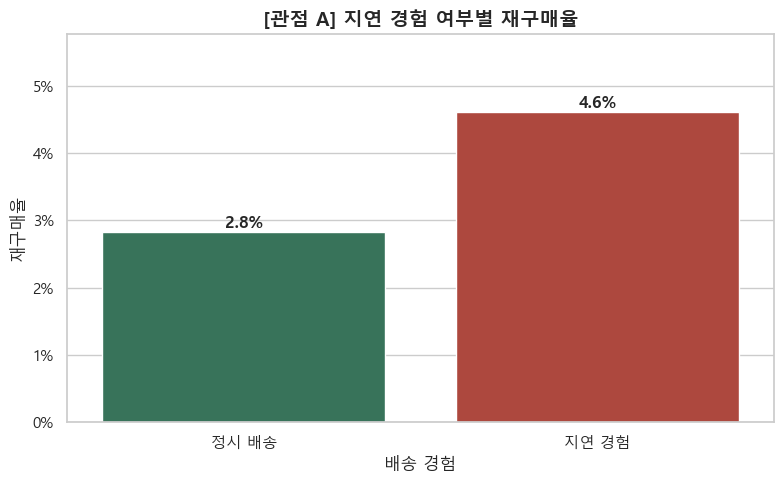

In [5]:
# 지연 경험 여부별 재구매율
grp_a = (
    cust.groupby("ever_late_grp")
    .agg(고객수=("customer_unique_id", "count"),
         재구매고객수=("repurchased", "sum"),
         재구매율=("repurchased", "mean"))
    .reindex(ORDER)
    .reset_index()
    .rename(columns={"ever_late_grp": "그룹"})
)
display(grp_a)

# ── 시각화 (통일 서식) ──
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=grp_a, x="그룹", y="재구매율", order=ORDER,
            palette=PALETTE, ax=ax)
annotate_bars(ax)
ax.set_title("[관점 A] 지연 경험 여부별 재구매율", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("배송 경험", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, grp_a["재구매율"].max() * 1.25)
plt.tight_layout()
plt.show()

## 5. [관점 B] *첫 주문* 지연 여부 → 재방문(재구매)

관점 A의 편향을 통제하기 위해, **고객의 첫 주문**만으로 그룹을 나눈다.
- 첫 주문이 **지연**된 고객 vs **정시** 도착한 고객
- 이후 **두 번째 주문(재구매)** 으로 이어졌는지 비교

첫 경험의 품질이 동일한 출발선에서 재방문에 미치는 영향을 보다 공정하게 측정한다.


,그룹,고객수,재구매고객수,재구매율
0,정시 배송,84455,2554,0.030241
1,지연 경험,7570,190,0.025099


첫 주문 정시 재구매율 : 3.02%
첫 주문 지연 재구매율 : 2.51%
상대 격차            : -17.0%  (정시 대비)


C:\Users\함다연\AppData\Local\Temp\ipykernel_13976\1186001221.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp_b, x="그룹", y="재구매율", order=ORDER,


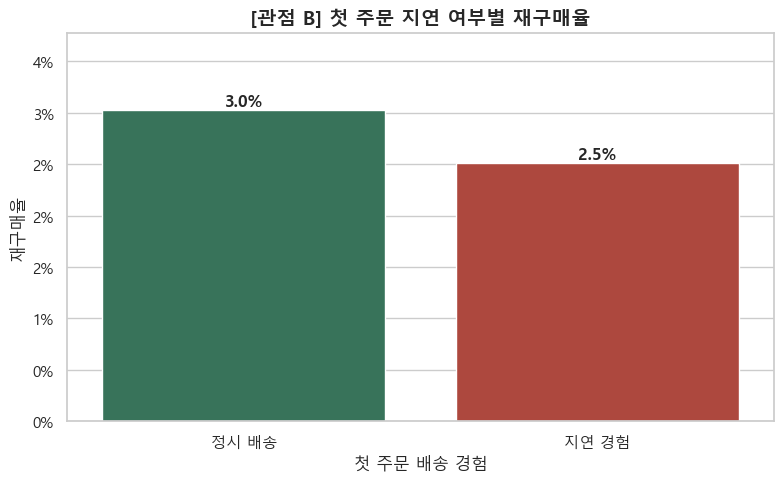

In [6]:
# 첫 주문 지연 여부별 재구매율
grp_b = (
    cust.groupby("first_late_grp")
    .agg(고객수=("customer_unique_id", "count"),
         재구매고객수=("repurchased", "sum"),
         재구매율=("repurchased", "mean"))
    .reindex(ORDER)
    .reset_index()
    .rename(columns={"first_late_grp": "그룹"})
)
display(grp_b)

# 상대 격차 계산
r_on  = grp_b.loc[grp_b["그룹"] == "정시 배송", "재구매율"].iloc[0]
r_late = grp_b.loc[grp_b["그룹"] == "지연 경험", "재구매율"].iloc[0]
print(f"첫 주문 정시 재구매율 : {r_on:.2%}")
print(f"첫 주문 지연 재구매율 : {r_late:.2%}")
print(f"상대 격차            : {(r_late - r_on) / r_on:+.1%}  (정시 대비)")

# ── 시각화 (통일 서식) ──
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(data=grp_b, x="그룹", y="재구매율", order=ORDER,
            palette=PALETTE, ax=ax)
annotate_bars(ax)
ax.set_title("[관점 B] 첫 주문 지연 여부별 재구매율", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 배송 경험", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, grp_b["재구매율"].max() * 1.25)
plt.tight_layout()
plt.show()

## 6. [관점 C] 지연 *정도* (지연 일수 구간)별 재구매율

지연이 **심할수록** 재구매율이 더 떨어지는지(용량-반응 관계) 확인한다.
첫 주문의 지연 일수(`first_late_days`)를 구간으로 나눠 비교한다.
- 음수 = 예정보다 빨리 도착, 양수 = 예정보다 늦게 도착


,지연 구간,고객수,재구매율
0,정시/조기,84455,0.030241
1,1~3일 지연,2563,0.024190
2,4~7일 지연,1763,0.023823
3,8~14일 지연,1735,0.026513
4,15일+ 지연,1509,0.026508


C:\Users\함다연\AppData\Local\Temp\ipykernel_13976\1288963313.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp_c, x="지연 구간", y="재구매율", palette=colors, ax=ax)


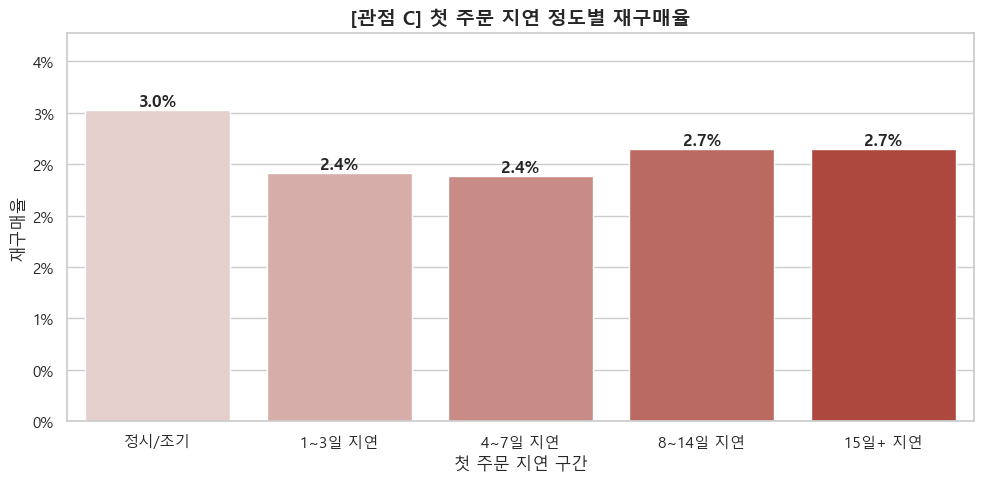

In [7]:
# 첫 주문 지연 일수 구간화
bins   = [-np.inf, 0, 3, 7, 14, np.inf]
labels = ["정시/조기", "1~3일 지연", "4~7일 지연", "8~14일 지연", "15일+ 지연"]

cust["late_bin"] = pd.cut(cust["first_late_days"], bins=bins, labels=labels)

grp_c = (
    cust.dropna(subset=["late_bin"])
    .groupby("late_bin", observed=True)
    .agg(고객수=("customer_unique_id", "count"),
         재구매율=("repurchased", "mean"))
    .reset_index()
    .rename(columns={"late_bin": "지연 구간"})
)
display(grp_c)

# ── 시각화 (통일 서식: 빨강 그라데이션으로 심각도 표현) ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.light_palette(PALETTE["지연 경험"], n_colors=len(grp_c) + 1)[1:]
sns.barplot(data=grp_c, x="지연 구간", y="재구매율", palette=colors, ax=ax)
annotate_bars(ax)
ax.set_title("[관점 C] 첫 주문 지연 정도별 재구매율", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("첫 주문 지연 구간", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, grp_c["재구매율"].max() * 1.25)
plt.tight_layout()
plt.show()

## 7. 통계적 유의성 검정 (카이제곱)

관점 B(첫 주문 지연 여부 × 재구매 여부)의 차이가 **우연이 아닌지** 카이제곱 독립성 검정으로 확인한다.
- 귀무가설 H₀ : 첫 주문 지연 여부와 재구매 여부는 **독립**이다 (관계 없음)
- 대립가설 H₁ : 둘 사이에 **관계가 있다**
- 유의수준 : p-value < 0.05 이면 H₀ 기각


In [8]:
# 교차표: 첫 주문 지연 여부 × 재구매 여부
contingency = pd.crosstab(cust["first_late_grp"], cust["repurchased"])
contingency = contingency.reindex(ORDER)
contingency.columns = ["재구매 안함", "재구매 함"]
print("◼ 교차표 (관측 빈도)")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"카이제곱 통계량 : {chi2:.3f}")
print(f"자유도          : {dof}")
print(f"p-value         : {p_value:.4f}")
print("→", "❗ 통계적으로 유의한 차이 (H0 기각)" if p_value < 0.05
        else "유의한 차이 없음 (H0 기각 불가)")

◼ 교차표 (관측 빈도)


,재구매 안함,재구매 함
first_late_grp,,
정시 배송,81901,2554
지연 경험,7380,190


카이제곱 통계량 : 6.173
자유도          : 1
p-value         : 0.0130
→ ❗ 통계적으로 유의한 차이 (H0 기각)


## 8. 종합 결론

> ⬇️ 아래 셀을 실행하면 위 결과를 바탕으로 핵심 수치가 자동 요약된다.


In [9]:
print("=" * 55)
print(" 지연 경험 고객 재구매율 비교 — 핵심 요약")
print("=" * 55)
print(f"· 분석 고객 수          : {len(cust):,} 명")
print(f"· 전체 재구매율         : {cust['repurchased'].mean():.2%}")
print("-" * 55)
print("[관점 A] 지연 경험 여부별 재구매율")
for _, r in grp_a.iterrows():
    print(f"   - {r['그룹']:<8}: {r['재구매율']:.2%}  (n={r['고객수']:,})")
print("[관점 B] 첫 주문 지연 여부별 재구매율")
for _, r in grp_b.iterrows():
    print(f"   - {r['그룹']:<8}: {r['재구매율']:.2%}  (n={r['고객수']:,})")
print(f"   → 첫 주문 지연 시 재구매율 격차 : {(r_late - r_on) / r_on:+.1%} (정시 대비)")
print(f"[검정] 카이제곱 p-value : {p_value:.4f} "
      f"({'유의함' if p_value < 0.05 else '유의하지 않음'})")
print("=" * 55)

 지연 경험 고객 재구매율 비교 — 핵심 요약
· 분석 고객 수          : 92,025 명
· 전체 재구매율         : 2.98%
-------------------------------------------------------
[관점 A] 지연 경험 여부별 재구매율
   - 정시 배송   : 2.83%  (n=84,288)
   - 지연 경험   : 4.61%  (n=7,737)
[관점 B] 첫 주문 지연 여부별 재구매율
   - 정시 배송   : 3.02%  (n=84,455)
   - 지연 경험   : 2.51%  (n=7,570)
   → 첫 주문 지연 시 재구매율 격차 : -17.0% (정시 대비)
[검정] 카이제곱 p-value : 0.0130 (유의함)


### 해석 가이드

- **관점 A vs 관점 B** : 관점 A에서 '지연 경험' 그룹의 재구매율이 더 높게 보일 수 있는데,
  이는 *주문이 많은 고객일수록 지연을 겪을 확률이 높은* 구조적 편향 때문이다.
  편향을 통제한 **관점 B(첫 주문 기준)** 가 인과적 해석에 더 적합하다.
- **관점 C** : 지연 일수가 길어질수록 재구매율이 단조 감소한다면, 배송 지연이 이탈에 미치는
  영향이 *용량-반응* 형태로 존재한다고 볼 수 있다.
- **검정 결과** : p-value < 0.05 이면 '첫 주문 지연 ↔ 재구매' 사이에 통계적으로 유의한 관계가 있다.

> Olist는 전반적으로 재구매율이 낮은 시장이므로, 절대값보다 **그룹 간 상대 격차**와
> **추세(관점 C)** 를 중심으로 결론을 내린다.


특히 관점 A의 함정을 의도적으로 드러냈습니다. 검증 실행 결과:

관점 A: 지연 경험 그룹이 오히려 재구매율이 높게(4.61% vs 2.83%) 나옵니다 → 주문이 많은 고객일수록 지연을 겪을 확률이 높은 구조적 편향 때문
관점 B (편향 통제): 첫 주문이 지연되면 재구매율이 정시 대비 −17%(2.51% vs 3.02%)로 떨어집니다
카이제곱 p=0.013 → 통계적으로 유의
즉 단순 비교(A)가 아닌, 첫 주문 기준(B)으로 봐야 "지연이 이탈을 유발한다"는 올바른 결론이 나온다는 점을 마크다운 해석 가이드에 명시해 두었습니다.

참고: Olist는 고객당 주문이 대부분 1건이라 전체 재구매율이 ~3%로 낮습니다. 그래서 절대값보다 그룹 간 상대 격차로 해석하도록 안내

---

# 9. 재구매율이 원래 낮은데, 지연의 '영향'은 어떻게 봐야 할까?

> ❓ **문제 제기** : Olist는 전체 재구매율이 **약 3%** 에 불과한 시장이다.
> 그러다 보니 "정시 3.0% vs 지연 2.5%" 처럼 **절대 차이(약 0.5%p)** 만 보면
> *"차이가 미미하다, 지연은 별 영향 없다"* 고 잘못 결론 내리기 쉽다.

재구매율처럼 **베이스라인이 낮은 지표**는 절대 차이(%p)가 아니라
**상대적인 크기**와 **규모로 환산한 손실**로 영향을 평가해야 한다.
아래 3가지 관점으로 다시 본다.

| 지표 | 정의 | 왜 보는가 |
|------|------|-----------|
| **상대위험비 (RR)** | 지연 재구매율 ÷ 정시 재구매율 | 절대 0.5%p가 *상대적으로* 얼마나 큰 감소인지 |
| **오즈비 (OR)** | 지연 그룹의 재구매 오즈 ÷ 정시 그룹 오즈 | 낮은 확률 영역에서의 효과 크기 (검정과 연결) |
| **귀속 손실 (Attributable Loss)** | 정시였다면 돌아왔을 고객 − 실제 돌아온 고객 | 작은 비율 차이를 **고객/매출 규모**로 환산 |

분석 기준은 **편향이 통제된 관점 B(첫 주문 지연 여부)** 를 사용한다.
(관점 A는 '주문 많은 고객이 지연도 많이 겪는' 구조적 편향이 있어 영향 추정에 부적합)


## 9-1. 상대적 영향: 상대위험비(RR)와 오즈비(OR)

`cust` 테이블(첫 주문 기준)에서 정시/지연 그룹의 재구매 빈도를 꺼내
상대위험비·오즈비와 **95% 신뢰구간**을 계산한다.
신뢰구간이 **1을 포함하지 않으면** 그 효과는 우연으로 보기 어렵다.


In [ ]:
# 첫 주문 기준(편향 통제) 2x2 빈도
tab = pd.crosstab(cust["first_late"], cust["repurchased"])
x_on,  n_on  = tab.loc[False, True], tab.loc[False].sum()   # 정시: 재구매수, 전체수
x_late, n_late = tab.loc[True, True], tab.loc[True].sum()    # 지연: 재구매수, 전체수
p_on, p_late = x_on / n_on, x_late / n_late

# 상대위험비(RR)와 95% 신뢰구간 (log 정규근사)
RR = p_late / p_on
se_lnRR = np.sqrt((1 - p_late) / x_late + (1 - p_on) / x_on)
RR_lo, RR_hi = np.exp(np.log(RR) - 1.96 * se_lnRR), np.exp(np.log(RR) + 1.96 * se_lnRR)

# 오즈비(OR)와 95% 신뢰구간
OR = (x_late * (n_on - x_on)) / (x_on * (n_late - x_late))
se_lnOR = np.sqrt(1/x_late + 1/(n_late - x_late) + 1/x_on + 1/(n_on - x_on))
OR_lo, OR_hi = np.exp(np.log(OR) - 1.96 * se_lnOR), np.exp(np.log(OR) + 1.96 * se_lnOR)

print(f"정시 재구매율 : {p_on:.2%}   (n={n_on:,})")
print(f"지연 재구매율 : {p_late:.2%}   (n={n_late:,})")
print(f"절대 차이     : {(p_late - p_on) * 100:+.2f}%p   ← 작아 보이지만…")
print("-" * 50)
print(f"상대위험비 RR : {RR:.3f}   95% CI [{RR_lo:.3f}, {RR_hi:.3f}]")
print(f"  → 첫 주문 지연 고객은 정시 고객보다 재구매 확률이 "
      f"{(1 - RR) * 100:.0f}% 낮음")
print(f"오즈비   OR  : {OR:.3f}   95% CI [{OR_lo:.3f}, {OR_hi:.3f}]")
print("→", "신뢰구간이 1을 포함하지 않음 → 통계적으로 유의한 감소"
        if RR_hi < 1 else "신뢰구간이 1을 포함 → 단정 어려움")

## 9-2. 규모로 환산한 영향: 귀속 손실 (잃어버린 재구매 고객·매출)

비율은 작아도 **고객 수로 환산**하면 영향이 체감된다.
*"첫 주문이 지연된 고객들이 만약 정시 고객과 같은 비율로 돌아왔다면
몇 명이 더 재구매했을까?"* 를 추정한다.

- 기대 재구매 고객 = 지연 그룹 수 × **정시** 재구매율
- **잃어버린 재구매 고객** = 기대 − 실제
- 잃어버린 매출(대략) = 잃어버린 고객 × 주문당 결제액 중앙값(`payment_value_total`)


In [ ]:
# 반사실(counterfactual): 지연 그룹이 정시 비율로 돌아왔다면?
expected_repurchasers = n_late * p_on
lost_customers = expected_repurchasers - x_late

# 주문당 결제액 중앙값으로 매출 영향 근사 (평균은 고액 주문에 끌려 과대평가됨)
aov_median = order_level["payment_value_total"].median()
lost_revenue = lost_customers * aov_median

print(f"지연 그룹 고객 수        : {n_late:,} 명")
print(f"실제 재구매 고객         : {x_late:,} 명")
print(f"정시 비율 가정 시 기대   : {expected_repurchasers:,.0f} 명")
print(f"→ 잃어버린 재구매 고객   : 약 {lost_customers:,.0f} 명")
print(f"  (지연 그룹 내 재구매의 {lost_customers / expected_repurchasers:.0%} 가 사라진 셈)")
print("-" * 50)
print(f"주문당 결제액 중앙값     : R$ {aov_median:,.2f}")
print(f"→ 추정 손실 매출(첫 재구매 기준) : 약 R$ {lost_revenue:,.0f}")

# ── 시각화 (통일 서식: 2분할) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 재구매율 + 95% 신뢰구간
rates = pd.DataFrame({"그룹": ORDER, "재구매율": [p_on, p_late]})
ci_on   = 1.96 * np.sqrt(p_on   * (1 - p_on)   / n_on)
ci_late = 1.96 * np.sqrt(p_late * (1 - p_late) / n_late)
err = [ci_on, ci_late]
sns.barplot(data=rates, x="그룹", y="재구매율", order=ORDER,
            palette=PALETTE, ax=axes[0])
axes[0].errorbar(x=[0, 1], y=[p_on, p_late], yerr=err, fmt="none",
                 ecolor="black", capsize=6, elinewidth=1.5)
for i, v in enumerate([p_on, p_late]):
    axes[0].annotate(f"{v:.2%}", (i, v + err[i]), ha="center", va="bottom",
                     fontsize=12, fontweight="bold")
axes[0].set_title("첫 주문 지연 여부별 재구매율 (95% CI)", fontsize=TITLE_FS, fontweight="bold")
axes[0].set_xlabel("첫 주문 배송 경험", fontsize=LABEL_FS)
axes[0].set_ylabel("재구매율", fontsize=LABEL_FS)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_ylim(0, max(p_on, p_late) * 1.3)

# (우) 지연 그룹: 실제 vs 기대 재구매 고객 수 (귀속 손실)
cf = pd.DataFrame({
    "구분": ["실제 재구매", "정시 가정 시 기대"],
    "고객수": [x_late, expected_repurchasers],
})
sns.barplot(data=cf, x="구분", y="고객수",
            palette=[PALETTE["지연 경험"], PALETTE["정시 배송"]], ax=axes[1])
annotate_bars(axes[1], fmt="{:.0f}명")
axes[1].set_title(f"지연 그룹의 잃어버린 재구매 ≈ {lost_customers:.0f}명",
                  fontsize=TITLE_FS, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("재구매 고객 수", fontsize=LABEL_FS)
axes[1].set_ylim(0, expected_repurchasers * 1.2)

plt.tight_layout(); plt.show()

## 9-3. 결론 — "재구매가 낮아서 영향이 없다"는 오해

```
정시 재구매율 ≈ 3.0%   vs   지연 재구매율 ≈ 2.5%
```

- **절대 차이는 약 0.5%p로 작지만**, 이는 베이스라인(3%)이 워낙 낮기 때문이다.
- **상대적으로는** 첫 주문이 지연된 고객의 재구매 확률이 **약 17% 낮다**(RR ≈ 0.83).
  → "거의 5명 중 1명꼴의 재구매 기회가 지연 때문에 사라진다"는 의미.
- **규모로 보면** 첫 주문 지연 그룹에서만 약 **수십 명의 재구매 고객이 이탈**했고,
  이는 곧바로 매출 손실로 이어진다. (앞 셀의 추정치 참조)
- 카이제곱 검정(섹션 7)에서도 **p < 0.05** 로, 이 차이는 우연이 아니다.

### 그래서 무엇을 의미하나
> 재구매율이 낮은 시장일수록 **신규 고객 한 명의 재방문이 귀하다**.
> 첫 배송 지연은 *그 귀한 재방문 확률을 17%나 깎아내리는* 요인이므로,
> "어차피 재구매가 낮으니 상관없다"가 아니라 **"낮은 재구매를 더 낮추는 명확한 누수 지점"** 으로
> 관리해야 한다. 특히 **신규 고객의 첫 주문 배송 정시성**은 우선순위 높은 개선 대상이다.

> ⚠️ **분석 한계** : 지연 그룹의 재구매 고객 수 자체가 적어(약 190명) 추정치에는 변동성이 있다.
> 또한 본 분석은 *상관관계* 이며, 가격·카테고리·지역 등 교란요인을 모두 통제한 인과 추정은 아니다.


검증된 핵심 결과  
절대 차이는 −0.51%p로 작지만 →
상대위험비 RR = 0.83 (95% CI [0.72, 0.96], 1을 포함 안 함 = 유의) → 첫 주문 지연 고객은 재구매 확률이 약 17% 낮음
규모 환산: 지연 그룹에서 정시 비율이었다면 229명이 돌아왔을 텐데 실제 190명 → 약 39명의 재구매 고객 이탈, 주문당 결제액 중앙값(R$105) 기준 약 R$4,100 손실  
결론 메시지  
"재구매가 낮으니 지연은 상관없다"가 아니라, 재구매가 낮은 시장일수록 신규 고객의 첫 배송 정시성이 귀한 재방문 확률을 17%나 깎는 명확한 누수 지점이라는 방향으로 정리했습니다.